In [25]:
import pandas as pd
import re
from textwrap import dedent

In [1]:
import cv2

VIDEO_PATH = "data/A01_20260221111246.mp4"  # <-- change this to your actual path

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frames / fps

print(f"Resolution : {width} x {height}")
print(f"FPS        : {fps:.2f}")
print(f"Total frames: {frames}")
print(f"Duration   : {duration:.1f} seconds ({duration / 60:.1f} min)")

cap.release()

Resolution : 2560 x 1952
FPS        : 12.00
Total frames: 10781
Duration   : 898.4 seconds (15.0 min)


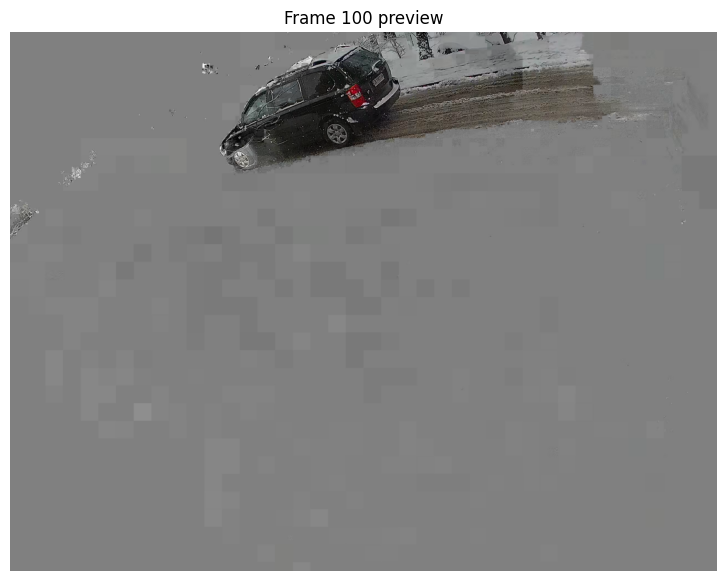

In [32]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 85)  # jump to frame 100
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)
plt.title("Frame 100 preview")
plt.axis("off")
plt.show()


0: 512x640 (no detections), 29.9ms
Speed: 1.9ms preprocess, 29.9ms inference, 0.3ms postprocess per image at shape (1, 3, 512, 640)


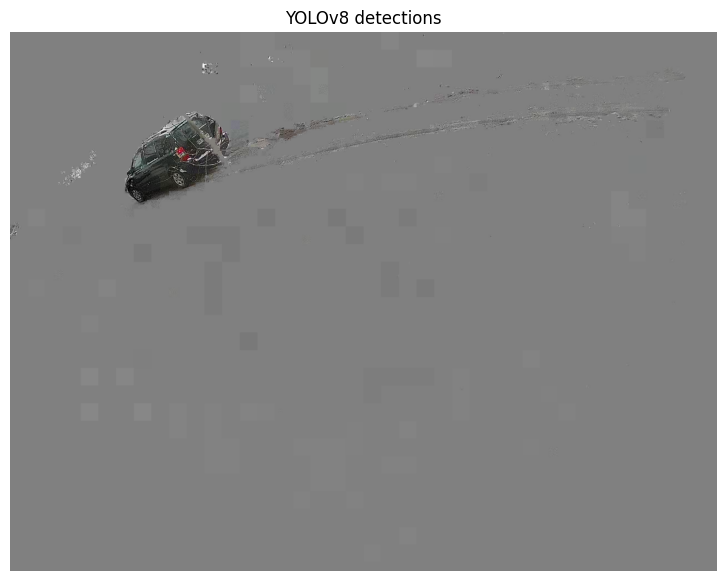

In [9]:
from ultralytics import YOLO

# Downloads ~6MB model on first run
model = YOLO("yolov8n.pt")  # 'n' = nano, fast; swap for 'yolov8s.pt' for better accuracy

results = model(frame_rgb, classes=[0, 2, 5, 7])
# class IDs from COCO: 0=person, 2=car, 5=bus, 7=truck

annotated = results[0].plot()  # draws boxes + labels on the frame

plt.figure(figsize=(12, 7))
plt.imshow(annotated)
plt.title("YOLOv8 detections")
plt.axis("off")
plt.show()

# Print what was found
for box in results[0].boxes:
    cls_id = int(box.cls)
    label = model.names[cls_id]
    conf = float(box.conf)
    print(f"  {label:10s}  confidence: {conf:.2f}")

In [10]:
from collections import defaultdict
import supervision as sv

cap = cv2.VideoCapture(VIDEO_PATH)

# Sample every Nth frame to speed things up
SAMPLE_EVERY = 10  # increase to go faster, decrease for more detail

frame_idx = 0
counts_over_time = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % SAMPLE_EVERY == 0:
        results = model(frame, classes=[0, 2, 5, 7], verbose=False)
        detections = sv.Detections.from_ultralytics(results[0])

        counts = defaultdict(int)
        for cls_id in detections.class_id:
            counts[model.names[cls_id]] += 1

        counts_over_time.append({
            "frame": frame_idx,
            "time_s": frame_idx / fps,
            **counts
        })

    frame_idx += 1

cap.release()
print(f"Processed {len(counts_over_time)} sampled frames out of {frame_idx} total.")

Processed 1079 sampled frames out of 10782 total.


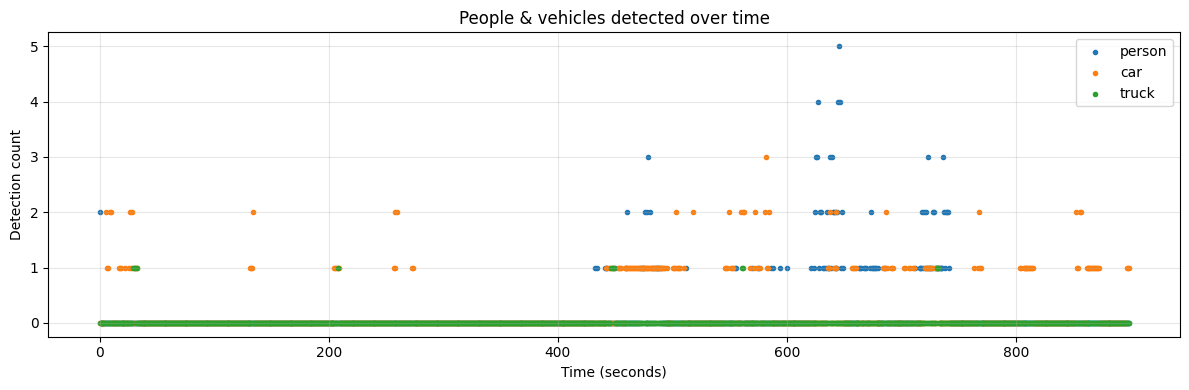

In [15]:
import pandas as pd

df = pd.DataFrame(counts_over_time).fillna(0)

plt.figure(figsize=(12, 4))
for col in ["person", "car", "bus", "truck"]:
    if col in df.columns:
        plt.scatter(df["time_s"], df[col], label=col, marker='.')

plt.xlabel("Time (seconds)")
plt.ylabel("Detection count")
plt.title("People & vehicles detected over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
with open('data/A01_20260221111246.txt', 'r') as f:
    logs = f.read()

logs

'***************************************************************\n*                                                             *\n*                                                             *\n***************************************************************\n\n84 logs output\n\n\nUser: admin Date:05/03/2026 Time: 21:28:48 made video export from device 0420241128CCWRFT4336051WCVU\n\n\n----------------------------\n1     2026-02-21 11:12:47\n----------------------------\nMajor Type: Information\nMinor Type: System Running Status\nLocal User: N/A\nHost IP Address: N/A\nParameter Type: N/A\nCamera No.: N/A\n\nChan[1][VIDEO] time[2026-02-21 11:12:47] cost[899 s] Opt[FINALIZE_FILE] Status[0] bFinal[0] HdNo[1] FileNo[1596] SegNo[6] eT[2026-02-21 11:12:46]\n\n\n\n----------------------------\n2     2026-02-21 11:12:47\n----------------------------\nMajor Type: Information\nMinor Type: System Running Status\nLocal User: N/A\nHost IP Address: N/A\nParameter Type: N/A\nCamera No.: N/A\n\nChan[1

In [11]:
pattern = '''\
----------------------------
(\\d+) (.+)
----------------------------
Major Type: (?!Information)(.+)
Minor Type: (.+)
Local User: .+
Host IP Address: .+
Parameter Type: .+
Camera No.: (.+)

(.+)
'''

raw_data = re.findall(pattern, logs)

In [18]:
events = pd.DataFrame(raw_data, columns=['event_id', 'timestamp', 'type_major', 'type_minor', 'camera', 'details'])
events.timestamp = pd.to_datetime(events.timestamp)
events.head()
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   event_id    56 non-null     str           
 1   timestamp   56 non-null     datetime64[us]
 2   type_major  56 non-null     str           
 3   type_minor  56 non-null     str           
 4   camera      56 non-null     str           
 5   details     56 non-null     str           
dtypes: datetime64[us](1), str(5)
memory usage: 2.8 KB


In [29]:
def parse_logs(filename):
    pattern = dedent('''\
    ----------------------------
    (\\d+) (.+)
    ----------------------------
    Major Type: (?!Information)(.+)
    Minor Type: (.+)
    Local User: .+
    Host IP Address: .+
    Parameter Type: .+
    Camera No.: (.+)

    (.+)
    ''')
    try:
        with open(filename, 'r') as f:
            rawdata = f.read()
    except FileNotFoundError:
        print(f'File {filename} not found.')
        return None

    matches = re.findall(pattern, rawdata)
    return  (
        pd.DataFrame(matches, columns=['event_id', 'timestamp', 'type', 'event', 'camera', 'detected'])
         .assign(timestamp=lambda df: pd.to_datetime(df.timestamp))
        .sort_values('timestamp')
        .set_index('timestamp')
        [[ 'type', 'event', 'camera', 'detected']]
    )

parse_logs('data/A01_20260221111246.txt')

,type,event,camera,detected
timestamp,,,,
2026-02-21 11:12:53,Alarm,Motion Detection Started,A1,Vehicle
2026-02-21 11:13:00,Alarm,Motion Detection Stopped,A1,Vehicle
2026-02-21 11:13:13,Alarm,Motion Detection Started,A1,Vehicle
2026-02-21 11:13:21,Alarm,Motion Detection Stopped,A1,Vehicle
2026-02-21 11:15:02,Alarm,Motion Detection Started,A1,Vehicle
2026-02-21 11:15:09,Alarm,Motion Detection Stopped,A1,Vehicle
2026-02-21 11:16:13,Alarm,Motion Detection Started,A1,Vehicle
2026-02-21 11:16:20,Alarm,Motion Detection Stopped,A1,Vehicle
2026-02-21 11:17:06,Alarm,Motion Detection Started,A1,Vehicle
